In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

%matplotlib inline

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
df=pd.read_csv("/content/framingham.csv")
print(f"Data Shape: {df.shape}")
print(f"Checkout Null Values: {df.isnull().sum()}")
print(f"Dataset Info: {df.info()}")
print(f"Dataset Description: {df.describe()}")
display(df.head())

Data Shape: (4240, 16)
Checkout Null Values: male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   di

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
median_cols = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']
for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

mode_cols = ['education', 'BPMeds']
for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [5]:
df = df.rename(columns={
    'male': 'Gender',
    'age': 'Age',
    'education': 'Education',
    'currentSmoker': 'Current_Smoker',
    'cigsPerDay': 'Cigarettes_Per_Day',
    'BPMeds': 'BP_Medication',
    'prevalentStroke': 'Prevalent_Stroke',
    'prevalentHyp': 'Prevalent_Hypertension',
    'diabetes': 'Diabetes',
    'totChol': 'Total_Cholesterol',
    'sysBP': 'Systolic_BP',
    'diaBP': 'Diastolic_BP',
    'BMI': 'BMI',
    'heartRate': 'Heart_Rate',
    'glucose': 'Glucose',
    'TenYearCHD': 'Ten_Year_CHD'
})

df.columns = df.columns.str.replace(' ', '_')
df.head()

,Gender,Age,Education,Current_Smoker,Cigarettes_Per_Day,BP_Medication,Prevalent_Stroke,Prevalent_Hypertension,Diabetes,Total_Cholesterol,Systolic_BP,Diastolic_BP,BMI,Heart_Rate,Glucose,Ten_Year_CHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


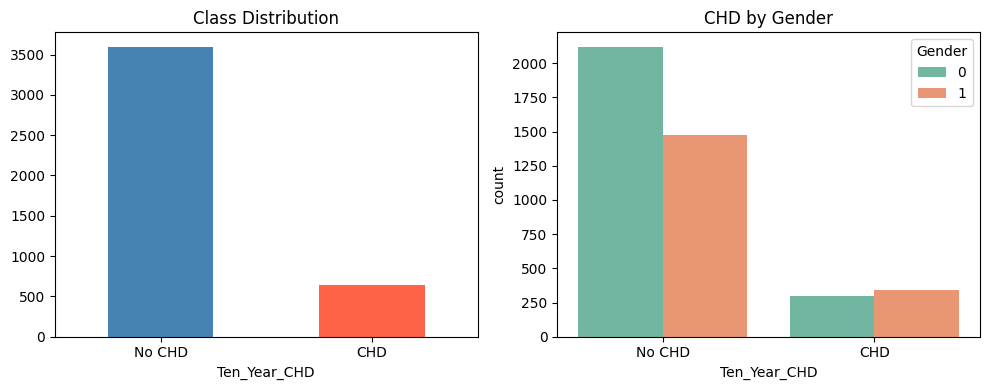

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Ten_Year_CHD'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['No CHD', 'CHD'], rotation=0)
sns.countplot(data=df, x='Ten_Year_CHD', hue='Gender', ax=axes[1], palette='Set2')
axes[1].set_title('CHD by Gender')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No CHD', 'CHD'])
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

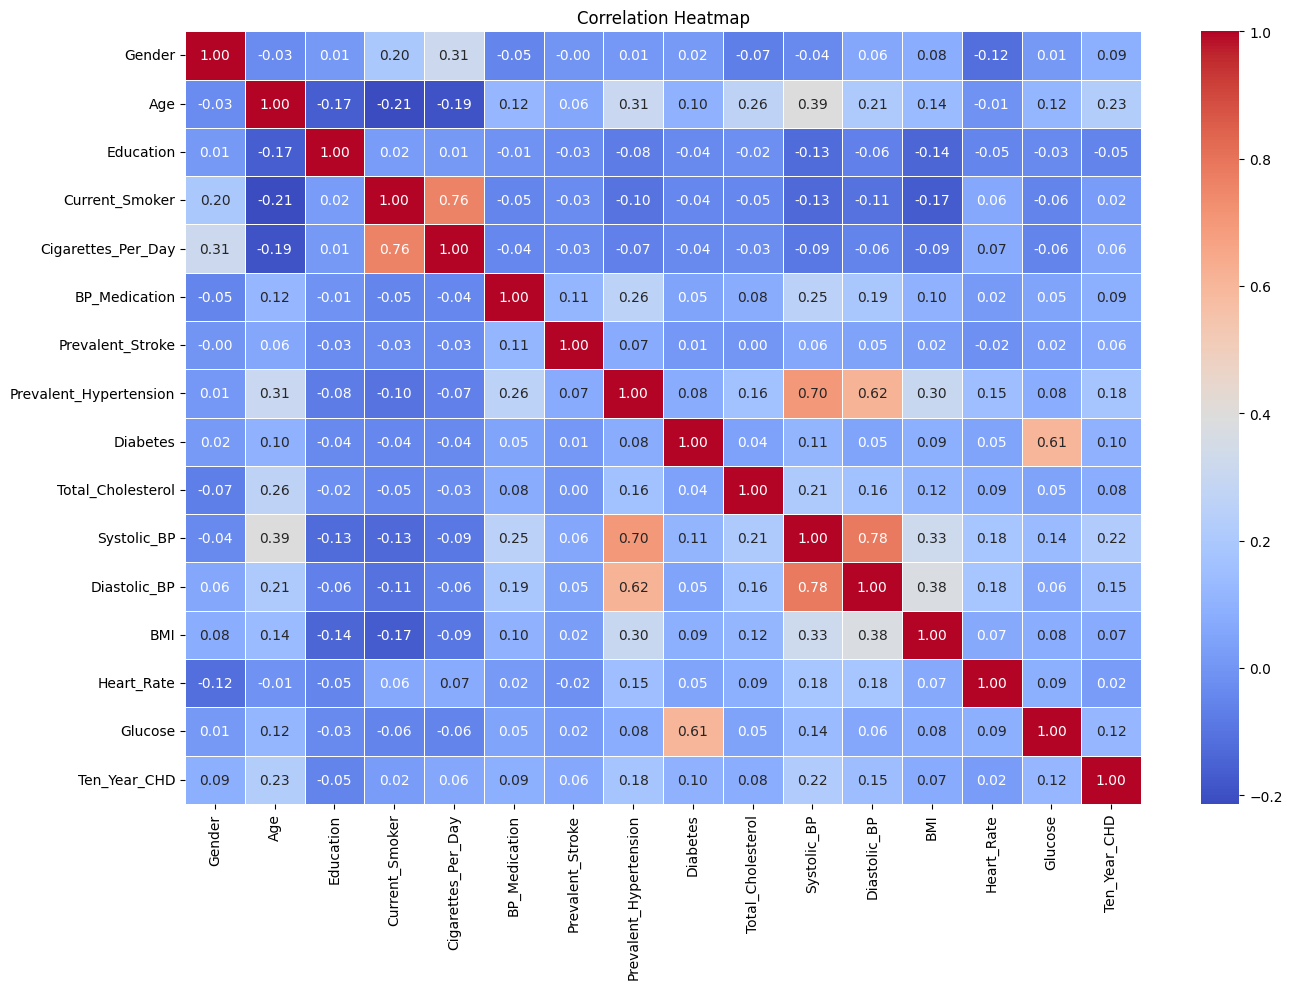

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

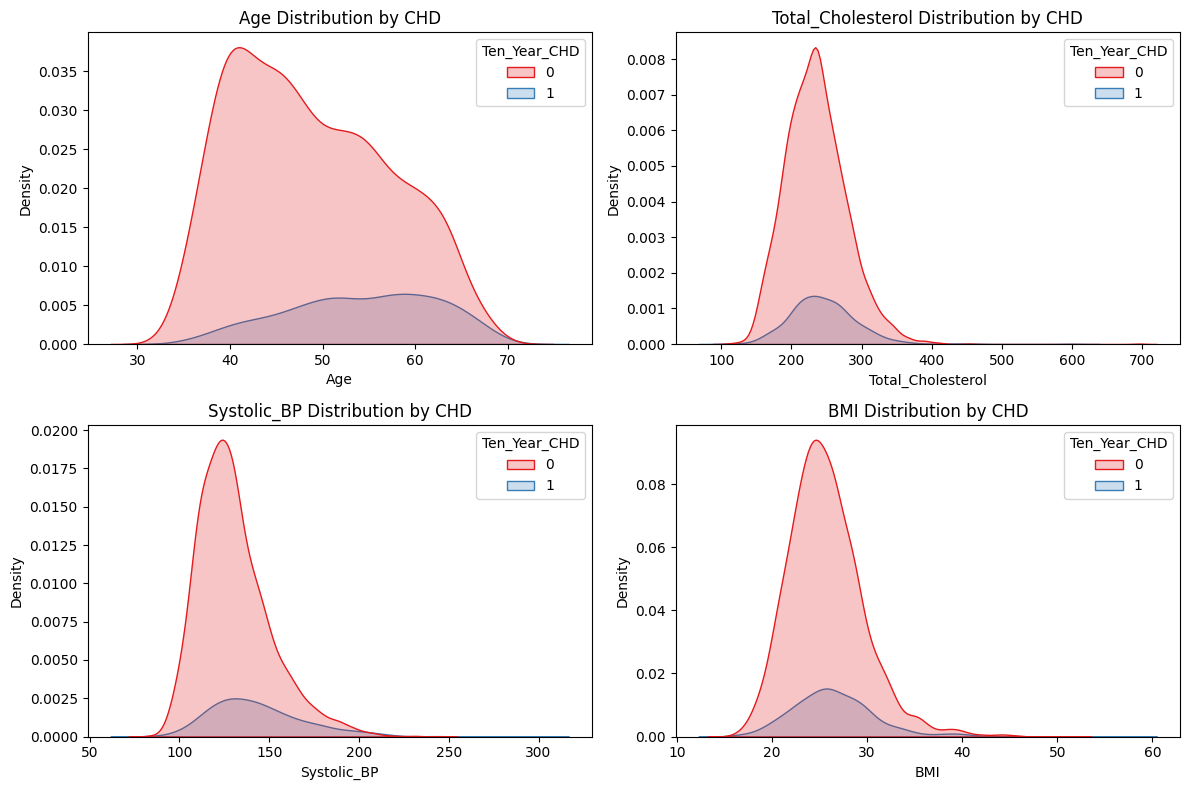

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['Age', 'Total_Cholesterol', 'Systolic_BP', 'BMI']):
    sns.kdeplot(data=df, x=col, hue='Ten_Year_CHD', ax=ax, fill=True, palette='Set1')
    ax.set_title(f'{col} Distribution by CHD')
plt.tight_layout()
plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
plt.show()

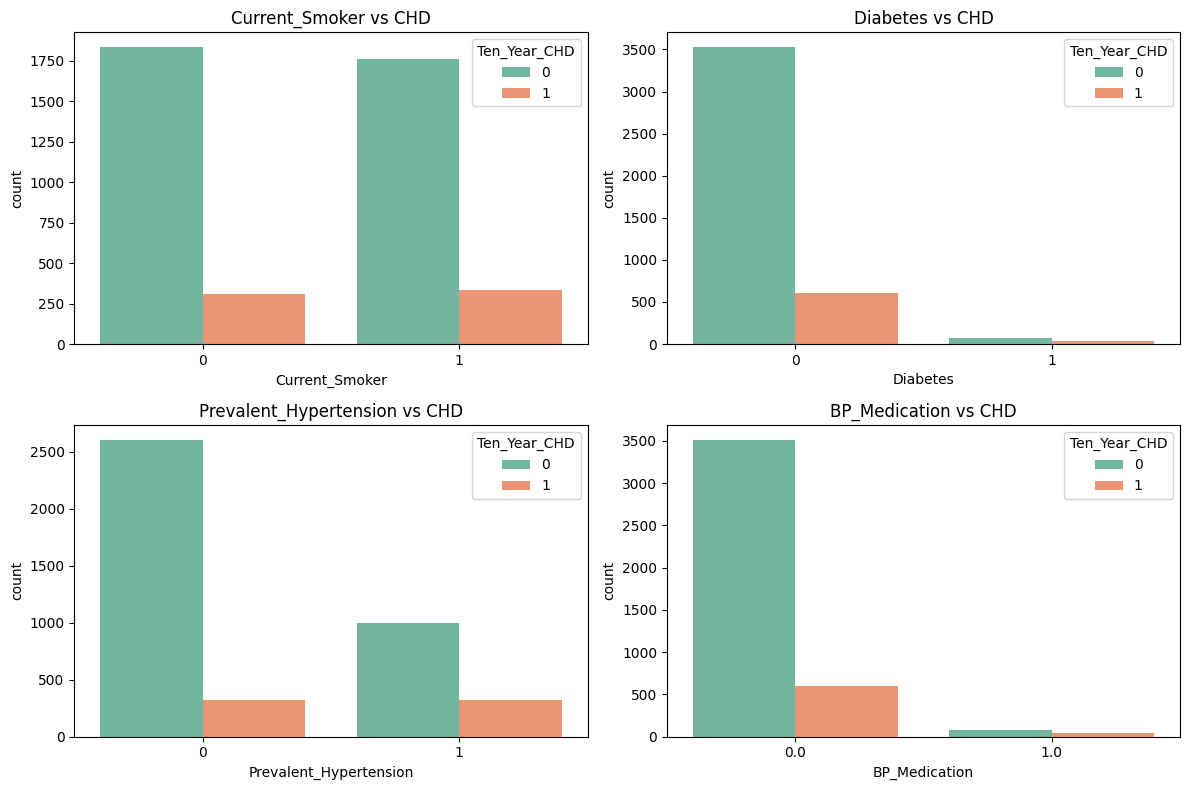

In [9]:
cat_cols = ['Current_Smoker', 'Diabetes', 'Prevalent_Hypertension', 'BP_Medication']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # flatten 2D array to 1D for easy looping

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue='Ten_Year_CHD', ax=ax, palette='Set2')
    ax.set_title(f'{col} vs CHD')

plt.tight_layout()
plt.savefig('categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']

In [11]:
df_majority = df[df['Ten_Year_CHD'] == 0]
df_minority = df[df['Ten_Year_CHD'] == 1]

df_minority_upsampled = resample(df_minority,
                                  replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
print(df_balanced['Ten_Year_CHD'].value_counts())


Ten_Year_CHD
0    3596
1    3596
Name: count, dtype: int64


In [12]:
X = df_balanced.drop('Ten_Year_CHD', axis=1)
y = df_balanced['Ten_Year_CHD']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


print(f"Train size : {X_train.shape}")
print(f"Val size   : {X_val.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (5753, 16)
Val size   : (719, 16)
Test size  : (720, 16)


In [14]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val.values).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 90
Val batches   : 12
Test batches  : 12


In [15]:
class TabAttention(nn.Module):
    def __init__(self, input_dim):
        super(TabAttention, self).__init__()
        self.fc = nn.Linear(input_dim, input_dim)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        weights = self.softmax(self.fc(x))
        return x * weights, weights

class AttentionDNN(nn.Module):
    def __init__(self, input_dim):
        super(AttentionDNN, self).__init__()

        self.attention = TabAttention(input_dim)

        self.block1 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.25)
        )

        self.block2 = nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.25)
        )

        self.block3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        self.skip1 = nn.Linear(input_dim, 128)
        self.skip2 = nn.Linear(128, 64)

        self.output = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x, attention_weights = self.attention(x)

        skip = self.skip1(x)
        x = self.block1(x)
        x = x + skip

        x = self.block2(x)

        skip2 = self.skip2(x)
        x = self.block3(x)
        x = x + skip2

        out = self.output(x)
        return out, attention_weights

input_dim = X_train.shape[1]
set_seed(42)
model_dnn = AttentionDNN(input_dim).to(device)
print(model_dnn)
print(f"\nTotal Parameters: {sum(p.numel() for p in model_dnn.parameters()):,}")

AttentionDNN(
  (attention): TabAttention(
    (fc): Linear(in_features=16, out_features=16, bias=True)
    (softmax): Softmax(dim=1)
  )
  (block1): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (skip1): Linear(in_features=16, out_features=128, bias=True)
  (skip2): Linear(in_features=128, out_fe

In [16]:
from torchsummary import summary
summary(model_dnn, input_size=(X_train.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]             272
           Softmax-2                   [-1, 16]               0
      TabAttention-3       [[-1, 16], [-1, 16]]               0
            Linear-4                  [-1, 128]           2,176
            Linear-5                  [-1, 128]           2,176
       BatchNorm1d-6                  [-1, 128]             256
              GELU-7                  [-1, 128]               0
           Dropout-8                  [-1, 128]               0
            Linear-9                  [-1, 128]          16,512
      BatchNorm1d-10                  [-1, 128]             256
             GELU-11                  [-1, 128]               0
          Dropout-12                  [-1, 128]               0
           Linear-13                   [-1, 64]           8,256
           Linear-14                   

In [17]:
from tqdm import tqdm

criterion = nn.BCELoss()
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

epochs = 200
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
early_stopping_patience = 50
early_stopping_counter = 0

for epoch in range(epochs):
    model_dnn.train()
    train_loss, train_correct, train_total = 0, 0, 0

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False)
    for X_batch, y_batch in loop:
        optimizer.zero_grad()
        outputs, _ = model_dnn(X_batch)
        loss = criterion(outputs.squeeze(), y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = (outputs.squeeze() > 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)
        loop.set_postfix(loss=loss.item())

    model_dnn.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs, _ = model_dnn(X_batch)
            loss = criterion(outputs.squeeze(), y_batch)
            val_loss += loss.item()
            preds = (outputs.squeeze() > 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
        torch.save(model_dnn.state_dict(), 'best_model.pth')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            tqdm.write(f"⏹ Early Stopping at Epoch {epoch+1}")
            break

    if (epoch+1) % 10 == 0:
        tqdm.write(f"Ep {epoch+1:3d} | TL: {train_loss:.4f} | TA: {train_acc:.4f} | VL: {val_loss:.4f} | VA: {val_acc:.4f}")

tqdm.write(f"✅ Done! Best Val Loss: {best_val_loss:.4f} | Total Epochs: {epoch+1}")

Ep  10 | TL: 0.5553 | TA: 0.7196 | VL: 0.5604 | VA: 0.7204


Ep  20 | TL: 0.5094 | TA: 0.7497 | VL: 0.5269 | VA: 0.7427


Ep  30 | TL: 0.4563 | TA: 0.7832 | VL: 0.4935 | VA: 0.7622


Ep  40 | TL: 0.4162 | TA: 0.8133 | VL: 0.4777 | VA: 0.7844


Ep  50 | TL: 0.3803 | TA: 0.8300 | VL: 0.4553 | VA: 0.8053


...

Ep 160 | TL: 0.2748 | TA: 0.8842 | VL: 0.3710 | VA: 0.8456


Ep 170 | TL: 0.2843 | TA: 0.8778 | VL: 0.3683 | VA: 0.8484


Ep 180 | TL: 0.2804 | TA: 0.8790 | VL: 0.3671 | VA: 0.8512


Ep 190 | TL: 0.2774 | TA: 0.8861 | VL: 0.3721 | VA: 0.8470


Ep 200 | TL: 0.2832 | TA: 0.8799 | VL: 0.3686 | VA: 0.8456
✅ Done! Best Val Loss: 0.3635 | Total Epochs: 200


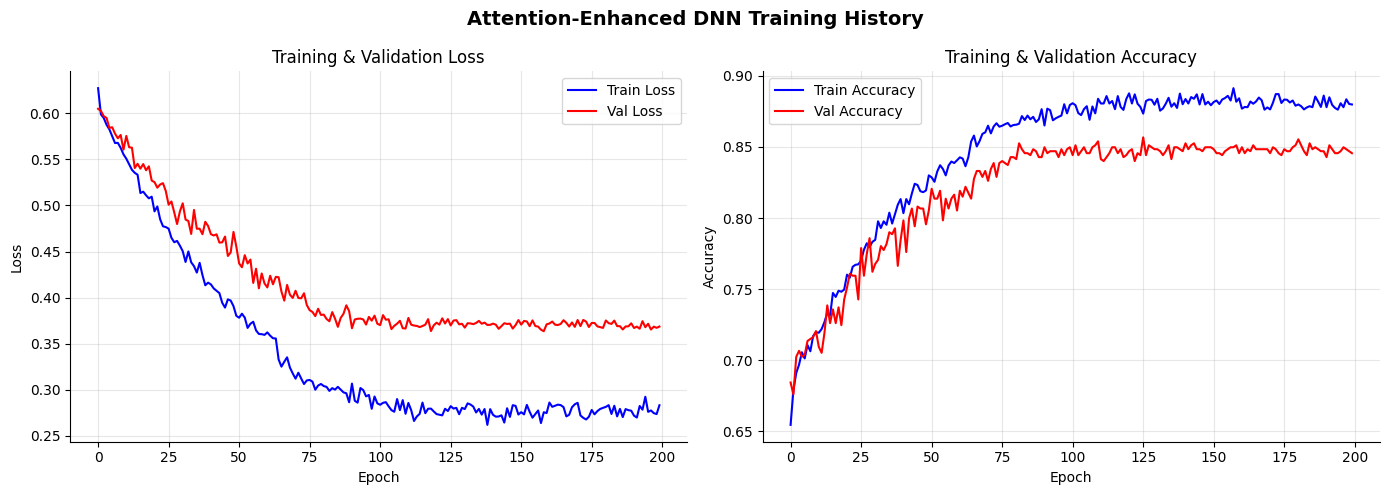

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
axes[1].plot(history['val_acc'], label='Val Accuracy', color='red')
axes[1].set_title('Training & Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Attention-Enhanced DNN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dnn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [20]:
best_model="/content/best_model.pth"
model_dnn.load_state_dict(torch.load(best_model))
model_dnn.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs, _ = model_dnn(X_batch)
        probs = outputs.squeeze().cpu().numpy()
        preds = (outputs.squeeze() > 0.5).float().cpu().numpy()
        labels = y_batch.cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)

dnn_acc = accuracy_score(all_labels, all_preds)
dnn_pre = precision_score(all_labels, all_preds)
dnn_rec = recall_score(all_labels, all_preds)
dnn_f1 = f1_score(all_labels, all_preds)
dnn_auc = roc_auc_score(all_labels, all_probs)

print(f"Accuracy  : {dnn_acc:.4f}")
print(f"Precision : {dnn_pre:.4f}")
print(f"Recall    : {dnn_rec:.4f}")
print(f"F1-Score  : {dnn_f1:.4f}")
print(f"ROC-AUC   : {dnn_auc:.4f}")


Accuracy  : 0.9000
Precision : 0.8655
Recall    : 0.9472
F1-Score  : 0.9045
ROC-AUC   : 0.9494


In [21]:
print(classification_report(all_labels, all_preds, target_names=["No CHD", "CHD"]))

              precision    recall  f1-score   support

      No CHD       0.94      0.85      0.90       360
         CHD       0.87      0.95      0.90       360

    accuracy                           0.90       720
   macro avg       0.90      0.90      0.90       720
weighted avg       0.90      0.90      0.90       720



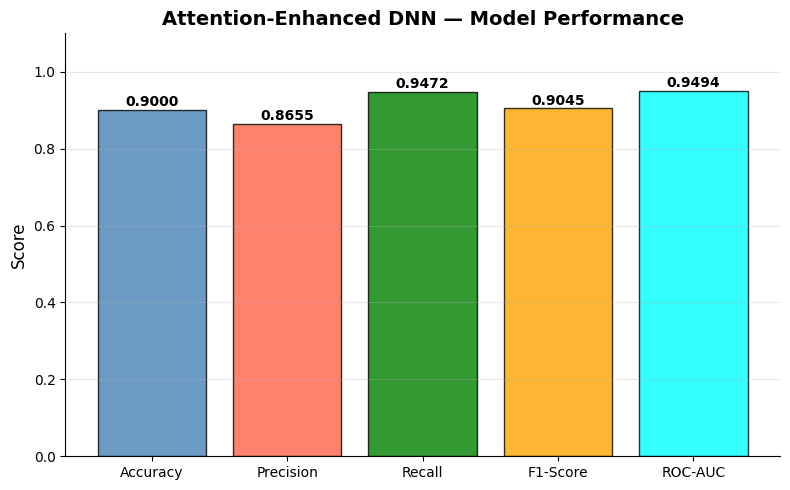

In [22]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [dnn_acc, dnn_pre, dnn_rec, dnn_f1, dnn_auc]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics, values, color=['steelblue','tomato','green','orange','cyan'], alpha=0.8, edgecolor='black')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Attention-Enhanced DNN — Model Performance', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('dnn_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

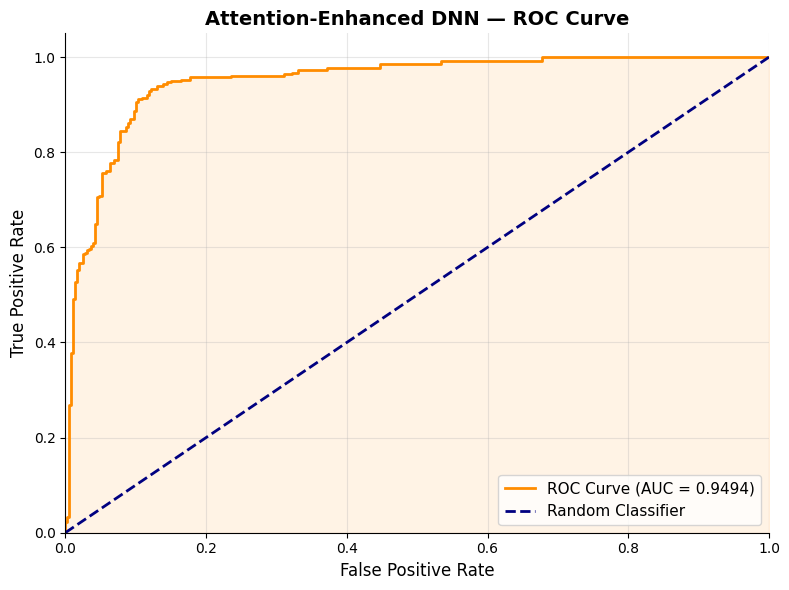

In [23]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Attention-Enhanced DNN — ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('dnn_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

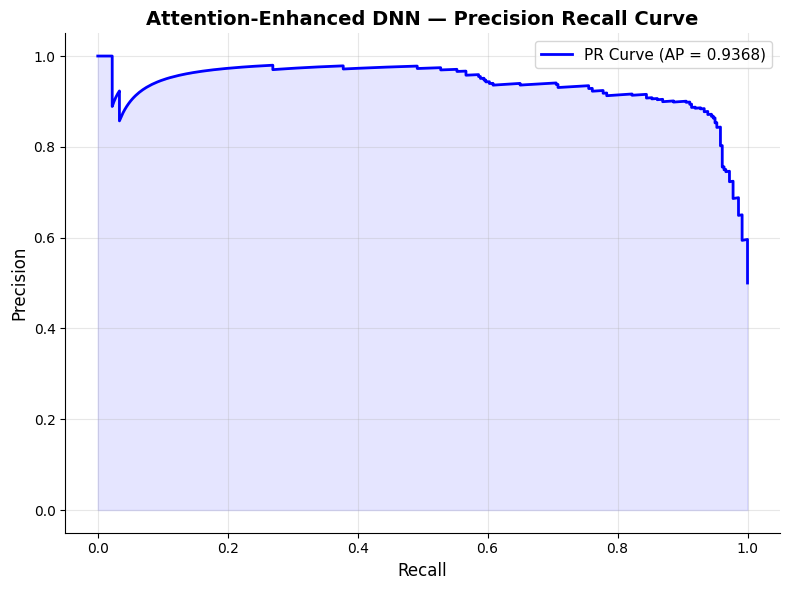

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
avg_precision = average_precision_score(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {avg_precision:.4f})')
ax.fill_between(recall, precision, alpha=0.1, color='blue')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Attention-Enhanced DNN — Precision Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('dnn_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

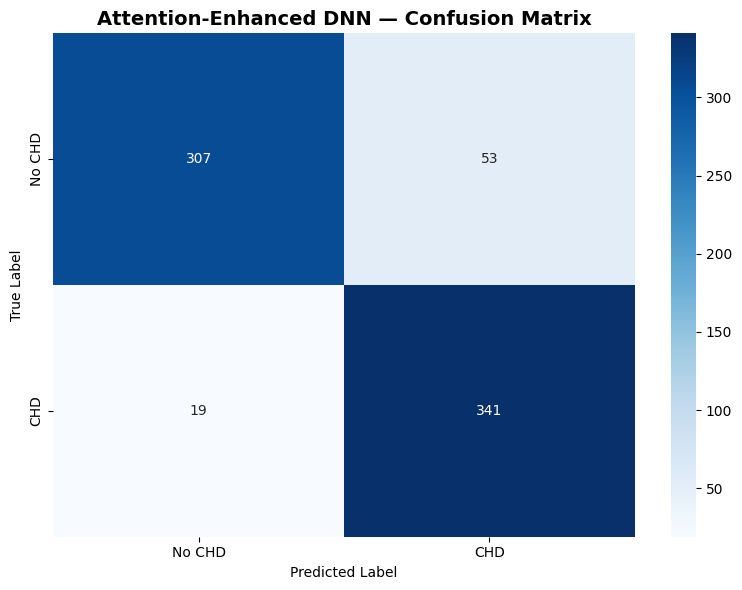

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No CHD', 'CHD'],
    yticklabels=['No CHD', 'CHD']
)

plt.title('Attention-Enhanced DNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('dnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

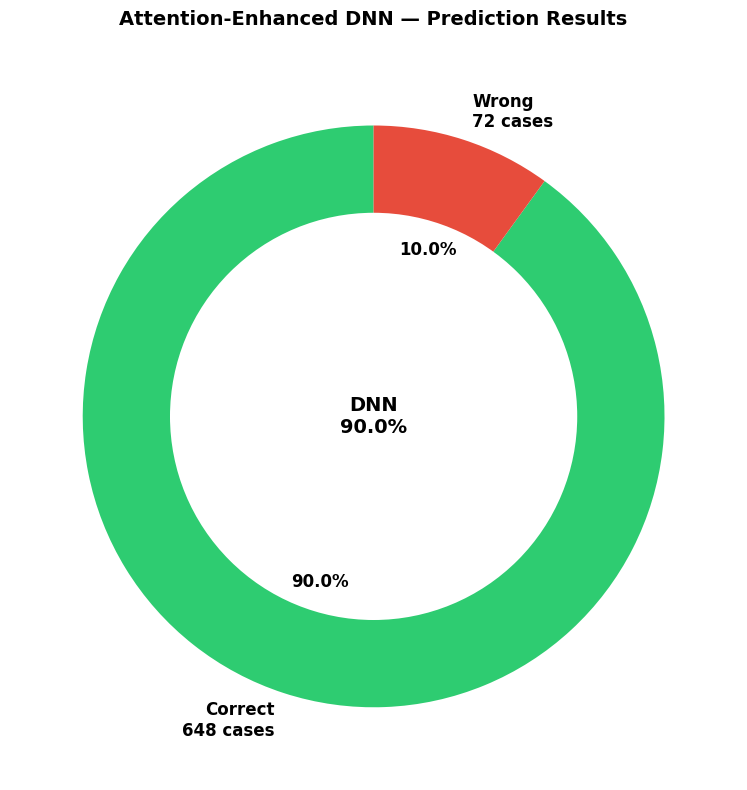

In [26]:
correct = int((np.array(all_labels) == np.array(all_preds)).sum())
wrong = int(len(all_labels) - correct)

fig, ax = plt.subplots(figsize=(8, 8))

sizes = [correct, wrong]
colors = ['#2ecc71', '#e74c3c']
labels = [f'Correct\n{correct} cases', f'Wrong\n{wrong} cases']

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.text(0, 0, f'DNN\n{dnn_acc*100:.1f}%', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title('Attention-Enhanced DNN — Prediction Results', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('dnn_donut.png', dpi=300, bbox_inches='tight')
plt.show()

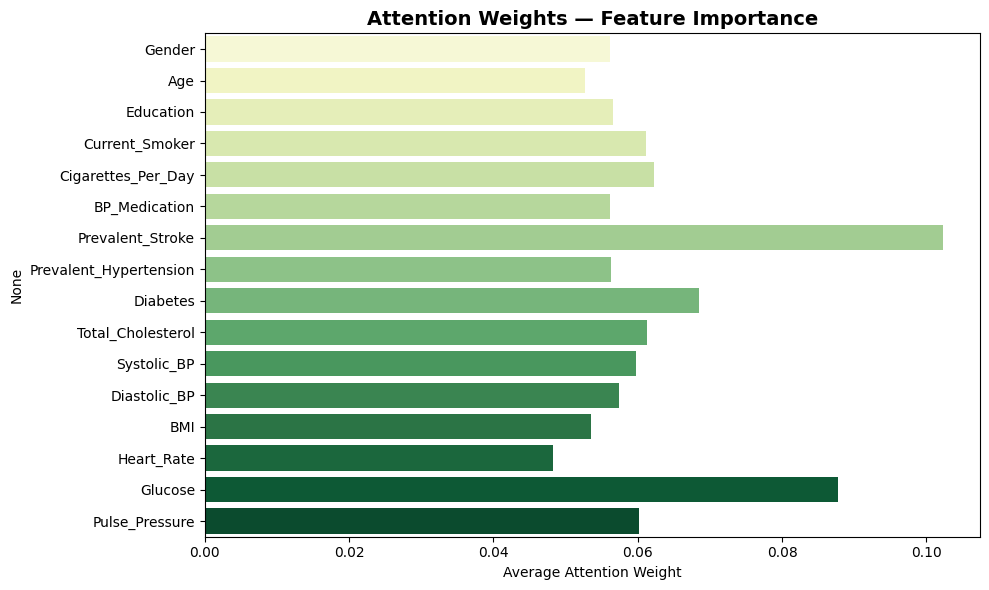

In [27]:
model_dnn.eval()
with torch.no_grad():
    _, attention_weights = model_dnn(X_test_tensor)

weights = attention_weights.cpu().numpy().mean(axis=0)
feature_names = df_balanced.drop('Ten_Year_CHD', axis=1).columns

plt.figure(figsize=(10, 6))
sns.barplot(x=weights, y=feature_names, hue=feature_names, legend=False, palette='YlGn')
plt.title('Attention Weights — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Average Attention Weight')
plt.tight_layout()
plt.savefig('attention_weights.png', dpi=300, bbox_inches='tight')
plt.show()

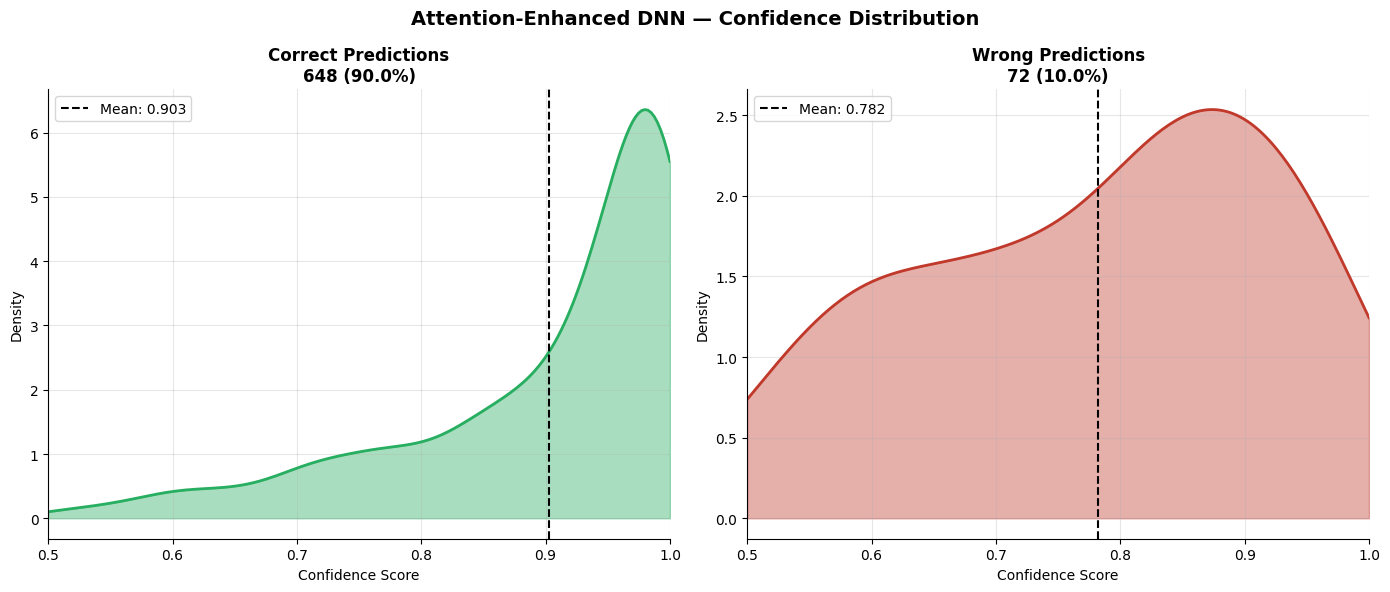

✅ Correct: 648 (90.0%)
❌ Wrong:   72 (10.0%)


In [28]:
from scipy.stats import gaussian_kde


correct = int((np.array(all_labels) == np.array(all_preds)).sum())
wrong = int(len(all_labels) - correct)

all_probs_arr = np.array(all_probs)
all_preds_arr = np.array(all_preds)
all_labels_arr = np.array(all_labels)

results_dnn = pd.DataFrame({
    'Actual': all_labels_arr,
    'Predicted': all_preds_arr,
    'Probability': all_probs_arr
})

results_dnn['Confidence'] = np.where(results_dnn['Probability'] > 0.5,
                                      results_dnn['Probability'],
                                      1 - results_dnn['Probability'])
results_dnn['Outcome'] = np.where(results_dnn['Actual'] == results_dnn['Predicted'], 'Correct', 'Wrong')

correct_df = results_dnn[results_dnn['Outcome'] == 'Correct']
wrong_df = results_dnn[results_dnn['Outcome'] == 'Wrong']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, subset, color, title in zip(axes,
                                     [correct_df, wrong_df],
                                     ['#27ae60', '#c0392b'],
                                     [f'Correct Predictions\n{len(correct_df)} ({len(correct_df)/len(results_dnn)*100:.1f}%)',
                                      f'Wrong Predictions\n{len(wrong_df)} ({len(wrong_df)/len(results_dnn)*100:.1f}%)']):
    kde = gaussian_kde(subset['Confidence'].values)
    xs = np.linspace(0.5, 1, 200)
    ax.fill_between(xs, kde(xs), alpha=0.4, color=color)
    ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(subset['Confidence'].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {subset["Confidence"].mean():.3f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Confidence Score')
    ax.set_ylabel('Density')
    ax.set_xlim(0.5, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Attention-Enhanced DNN — Confidence Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dnn_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Correct: {len(correct_df)} ({len(correct_df)/len(results_dnn)*100:.1f}%)")
print(f"❌ Wrong:   {len(wrong_df)} ({len(wrong_df)/len(results_dnn)*100:.1f}%)")